<a href="https://colab.research.google.com/github/ssmahadevcse2025/interpolation-search/blob/main/daae2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Dataset Size: 10000
Interpolation Search Probes: 1
Binary Search Comparisons: 2

Dataset Size: 50000
Interpolation Search Probes: 1
Binary Search Comparisons: 2

Dataset Size: 100000
Interpolation Search Probes: 1
Binary Search Comparisons: 2


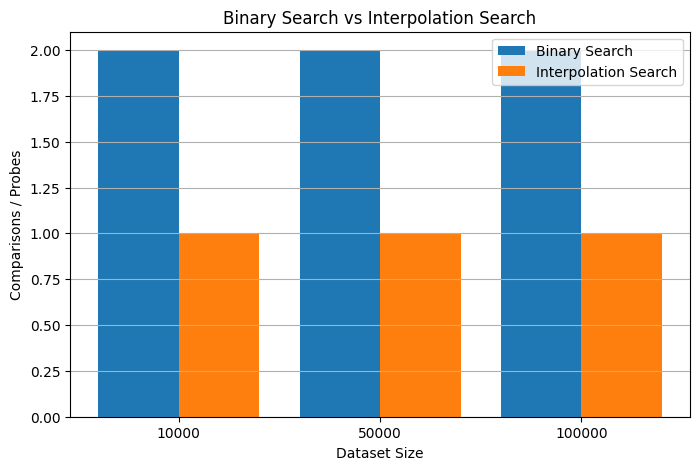

In [2]:
import matplotlib.pyplot as plt

def interpolation_search(arr, target):
    low, high = 0, len(arr) - 1
    probes = 0

    while low <= high and arr[low] <= target <= arr[high]:
        probes += 1

        if low == high:
            return low if arr[low] == target else -1, probes

        pos = low + int(
            ((target - arr[low]) * (high - low))
            / (arr[high] - arr[low])
        )

        if arr[pos] == target:
            return pos, probes
        elif arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1

    return -1, probes


def binary_search(arr, target):
    low, high = 0, len(arr) - 1
    comparisons = 0

    while low <= high:
        comparisons += 1

        mid = (low + high) // 2

        if arr[mid] == target:
            return mid, comparisons
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1

    return -1, comparisons


# Dataset sizes
sizes = [10000, 50000, 100000]

binary_results = []
interpolation_results = []

for n in sizes:
    arr = list(range(1, n + 1))

    target = int(n * 0.75)  # Search 75% position

    _, probes = interpolation_search(arr, target)
    _, comps = binary_search(arr, target)

    interpolation_results.append(probes)
    binary_results.append(comps)

    print(f"\nDataset Size: {n}")
    print(f"Interpolation Search Probes: {probes}")
    print(f"Binary Search Comparisons: {comps}")

# Analysis Chart
plt.figure(figsize=(8, 5))

x = range(len(sizes))

plt.bar(
    [i - 0.2 for i in x],
    binary_results,
    width=0.4,
    label="Binary Search"
)

plt.bar(
    [i + 0.2 for i in x],
    interpolation_results,
    width=0.4,
    label="Interpolation Search"
)

plt.xticks(x, sizes)
plt.xlabel("Dataset Size")
plt.ylabel("Comparisons / Probes")
plt.title("Binary Search vs Interpolation Search")
plt.legend()
plt.grid(axis="y")

plt.show()